XAFS Background is set.
<< Start fitting via Adapted EM Algorithm. >>
> iteration #  0, LL=-8.83005869e+08, residual=1.342e-01, elapsed time:  0.13 s


/Users/yasunobu/Documents/GitHub/EMPeaks/EMPeaks/Background/_background.py:215: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 / self.a * (+ np.log(np.cosh(self.a * (self.x_max - self.x0)))
/Users/yasunobu/Documents/GitHub/EMPeaks/EMPeaks/Background/_background.py:215: RuntimeWarning: invalid value encountered in double_scalars
  return 1 / self.a * (+ np.log(np.cosh(self.a * (self.x_max - self.x0)))


> iteration # 10, LL=-8.59283439e+08, residual=2.179e-04, elapsed time:  0.19 s
> iteration # 20, LL=-8.58174965e+08, residual=8.792e-05, elapsed time:  0.16 s
> iteration # 30, LL=-8.57555242e+08, residual=7.065e-05, elapsed time:  0.15 s
> iteration # 40, LL=-8.56730525e+08, residual=1.343e-04, elapsed time:  0.12 s
> iteration # 50, LL=-8.55652644e+08, residual=5.562e-05, elapsed time:  0.23 s
> iteration # 60, LL=-8.55538342e+08, residual=2.990e-06, elapsed time:  0.20 s
> iteration # 70, LL=-8.55524444e+08, residual=1.027e-06, elapsed time:  0.33 s
> iteration # 80, LL=-8.55518235e+08, residual=5.557e-07, elapsed time:  0.18 s
> iteration # 90, LL=-8.55514379e+08, residual=3.894e-07, elapsed time:  0.25 s
> iteration #100, LL=-8.55511376e+08, residual=3.283e-07, elapsed time:  0.25 s
> iteration #110, LL=-8.55508672e+08, residual=3.120e-07, elapsed time:  0.26 s
> iteration #120, LL=-8.55506024e+08, residual=3.122e-07, elapsed time:  0.25 s
> iteration #130, LL=-8.55503338e+08, re

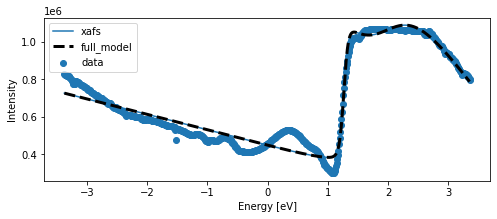

In [50]:
from EMPeaks.GaussianMixture import GaussianMixtureModel
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#f_name= 'Cu_foil_exafs'
#f_name= 'Cu_foil_xanes'
f_name= 'Nidien2Cl2'
#f_name= 'Nidien2ClO42'
with open(f_name, 'r') as f:
    lines = f.read().splitlines()
def inclucive_index(s, lines):
    return [s in l for l in lines].index(True)
s = 'Offset'
init = inclucive_index(s, lines)+1
data = [l.split() for l in lines[init:]]
db = pd.DataFrame(data).astype(float)
db.columns = ['Angle(c)', 'Angle(o)', 'time/s','2','3']
#d=-500
x = db['Angle(c)'][0:-2].to_numpy()
y = db['3'][0:-2].to_numpy()
x = x[::-1]*0.1
y = y[::-1]

d=675
x = x[:d]
y = y[:d]
x = np.arange(-d/200, d/200, 0.01)


#フィットするためのデータを生成します
#gmm_data =GaussianMixtureModel(K=3, background="uniform")
#param = {"mu":[-100, 0, 100], "pi":[0.1,0.1,0.1,0.4]}
#gmm_data.set_param(**param)

#データと初期パラメータのモデルをプロットします
#N = 1.0e+6
#y = N * gmm_data.predict(x) + np.random.poisson(10000, len(x))
gmm = GaussianMixtureModel(K=0, x_min=-d/200, x_max=d/200, background='xafs', postedge_order=1)
#gmm = GaussianMixtureModel(K=0, x_min=x[0], x_max=x[-1], background='xafs', postedge_order=1)
#gmm = GaussianMixtureModel(K=0, x_min=0, x_max=17.7, background='linear', sign='negative')
gmm.fit(x,y)
gmm.plot(x, y)
#print(gmm.model[0].s_tri)

課題は以下の２点
* coshのOverFlow問題（x軸の取り方で対応できる）
* uniformではないxサンプリングに対するweightの補正